In [1]:
import os, sys

print("CWD:", os.getcwd())
print("Python path:")
for p in sys.path:
    print(p)

CWD: /home/student2/ofml_workspace/OpenFastML/notebooks
Python path:
/home/student2/ofml_workspace/OpenFastML/conda/envs/fastml4jets/lib/python310.zip
/home/student2/ofml_workspace/OpenFastML/conda/envs/fastml4jets/lib/python3.10
/home/student2/ofml_workspace/OpenFastML/conda/envs/fastml4jets/lib/python3.10/lib-dynload

/home/student2/ofml_workspace/OpenFastML/conda/envs/fastml4jets/lib/python3.10/site-packages
__editable__.ofml-0.0.1.finder.__path_hook__


In [2]:
from data.opendataloader import OpenDataLoader
from fastml.modules.cnn import load_qCNN
from fastml.utils.image import pad
from fastml.utils_egamma.efex import eFex_slidingwindow_mask
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, auc


2026-06-24 10:07:17.662955: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-24 10:07:17.663025: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-24 10:07:17.663051: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-24 10:07:17.668781: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
og_model_path = '../models/cls_qcnn/baseline_model_64.keras'
root_model_path = '../models/root_qcnn/baseline_model_64.keras'

In [4]:
signal = ak.from_parquet('../test_data/test_signal.parquet')
background = ak.from_parquet('../test_data/test_background.parquet')
signal_meta = ak.metadata_from_parquet("../test_data/test_signal.parquet")

In [5]:
print(signal_meta["columns"])

['image.list.item.list.item.list.item.list.item', 'seed_info.list.item.rho', 'seed_info.list.item.phi', 'seed_info.list.item.eta', 'seed_info.list.item.tau']


In [6]:
og_model = load_qCNN(og_model_path)
root_model = load_qCNN(root_model_path)

/home/student2/ofml_workspace/OpenFastML/conda/envs/fastml4jets/lib/python3.10/site-packages/keras/src/constraints.py:365: UserWarning: The `keras.constraints.serialize()` API should only be used for objects of type `keras.constraints.Constraint`. Found an instance of type <class 'qkeras.quantizers.quantized_bits'>, which may lead to improper serialization.
  warnings.warn(


In [7]:
og_predictions = []
for dataset in [signal, background]:
    pred = og_model.predict(
        np.array(ak.flatten(dataset.image)),
        batch_size=1024,
        verbose=0
    )
    
    pred = pred[:,0,0,0]
    counts = ak.num(dataset.seed_info)
    og_predictions.append(ak.unflatten(pred, counts))
    
og_predictions = {
    "signal" : og_predictions[0],
    "background" : og_predictions[1]
}
root_predictions = []
for dataset in [signal, background]:
    pred = root_model.predict(
        np.array(ak.flatten(dataset.image)),
        batch_size=1024,
        verbose=0
    )
    
    pred = pred[:,0,0,0]
    counts = ak.num(dataset.seed_info)
    root_predictions.append(ak.unflatten(pred, counts))
    
root_predictions = {
    "signal" : root_predictions[0],
    "background" : root_predictions[1]
}

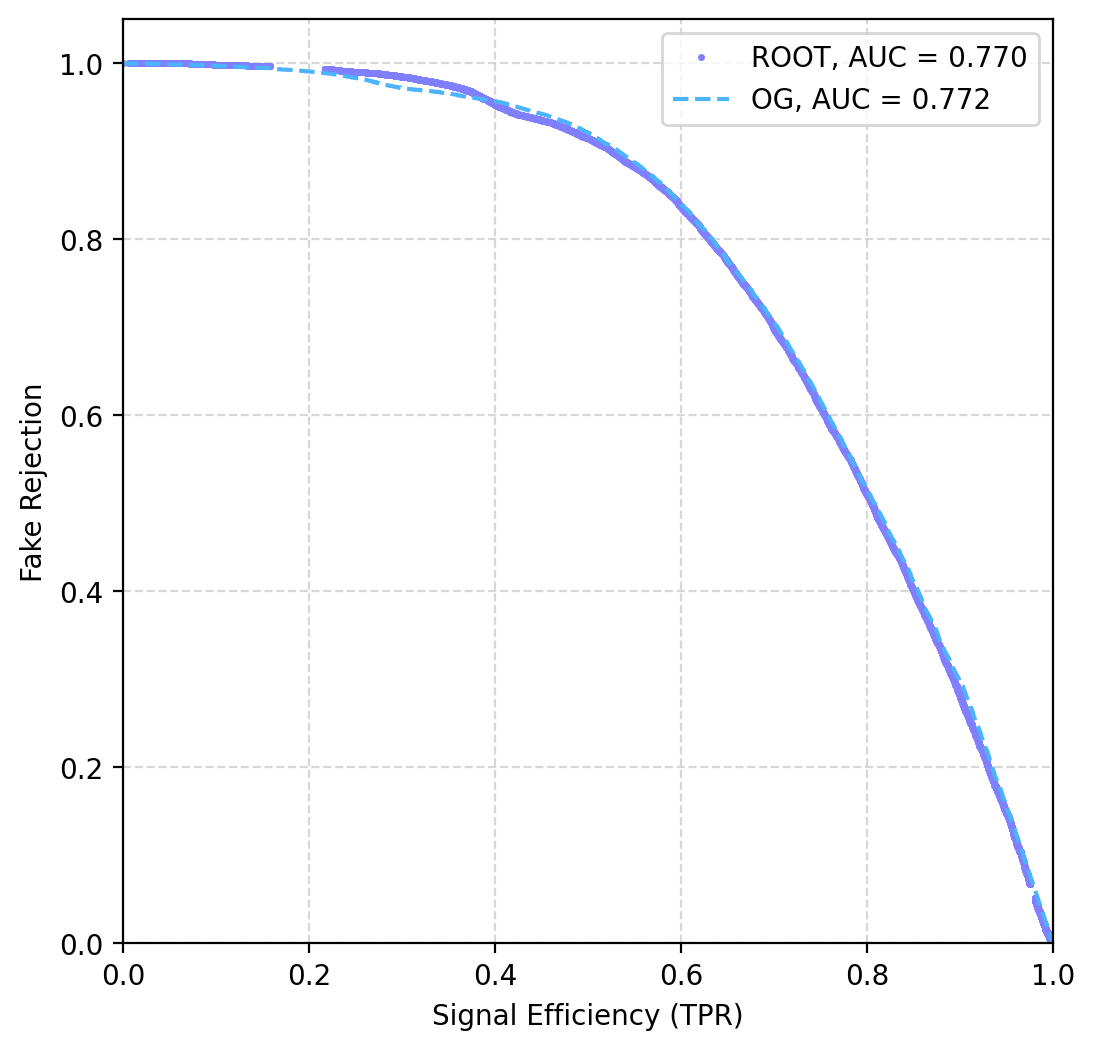

In [8]:
# ROOT predictions
y_sig_root = ak.flatten(root_predictions['signal'])
y_bkg_root = ak.flatten(root_predictions['background'][:len(y_sig_root)])

y_root = np.concatenate([np.ones_like(y_sig_root, dtype=int), np.zeros_like(y_bkg_root, dtype=int)])
s_root = np.concatenate([y_sig_root, y_bkg_root])

fpr_root, tpr_root, _ = roc_curve(y_root, s_root)
A_root = auc(fpr_root, tpr_root)

fake_rej_root = 1 - fpr_root

# OG predictions
y_sig_og = ak.flatten(og_predictions['signal'])
y_bkg_og = ak.flatten(og_predictions['background'][:len(y_sig_og)])

y_og = np.concatenate([np.ones_like(y_sig_og, dtype=int), np.zeros_like(y_bkg_og, dtype=int)])
s_og = np.concatenate([y_sig_og, y_bkg_og])

fpr_og, tpr_og, _ = roc_curve(y_og, s_og)
A_og = auc(fpr_og, tpr_og)

fake_rej_og = 1 - fpr_og

plt.figure(figsize=(6, 6), dpi=200)
plt.plot(tpr_root, fake_rej_root, ".", ms=3, color=plt.cm.cool(0.5), label=f"ROOT, AUC = {A_root:.3f}")
plt.plot(tpr_og, fake_rej_og, "--", color=plt.cm.cool(0.3), label=f"OG, AUC = {A_og:.3f}")

plt.xlim(0, 1)
plt.ylim(0, 1.05)
plt.xlabel("Signal Efficiency (TPR)")
plt.ylabel("Fake Rejection")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.show()

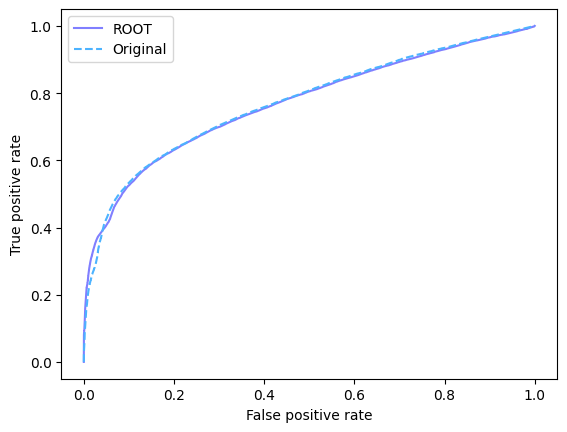

In [9]:
# ROC Curves
fig = plt.figure()
ax = plt.axes()
ax.plot(fpr_root, tpr_root, color=plt.cm.cool(0.5), label="ROOT")
ax.plot(fpr_og, tpr_og, color=plt.cm.cool(0.3), linestyle="--", label="Original")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.legend()

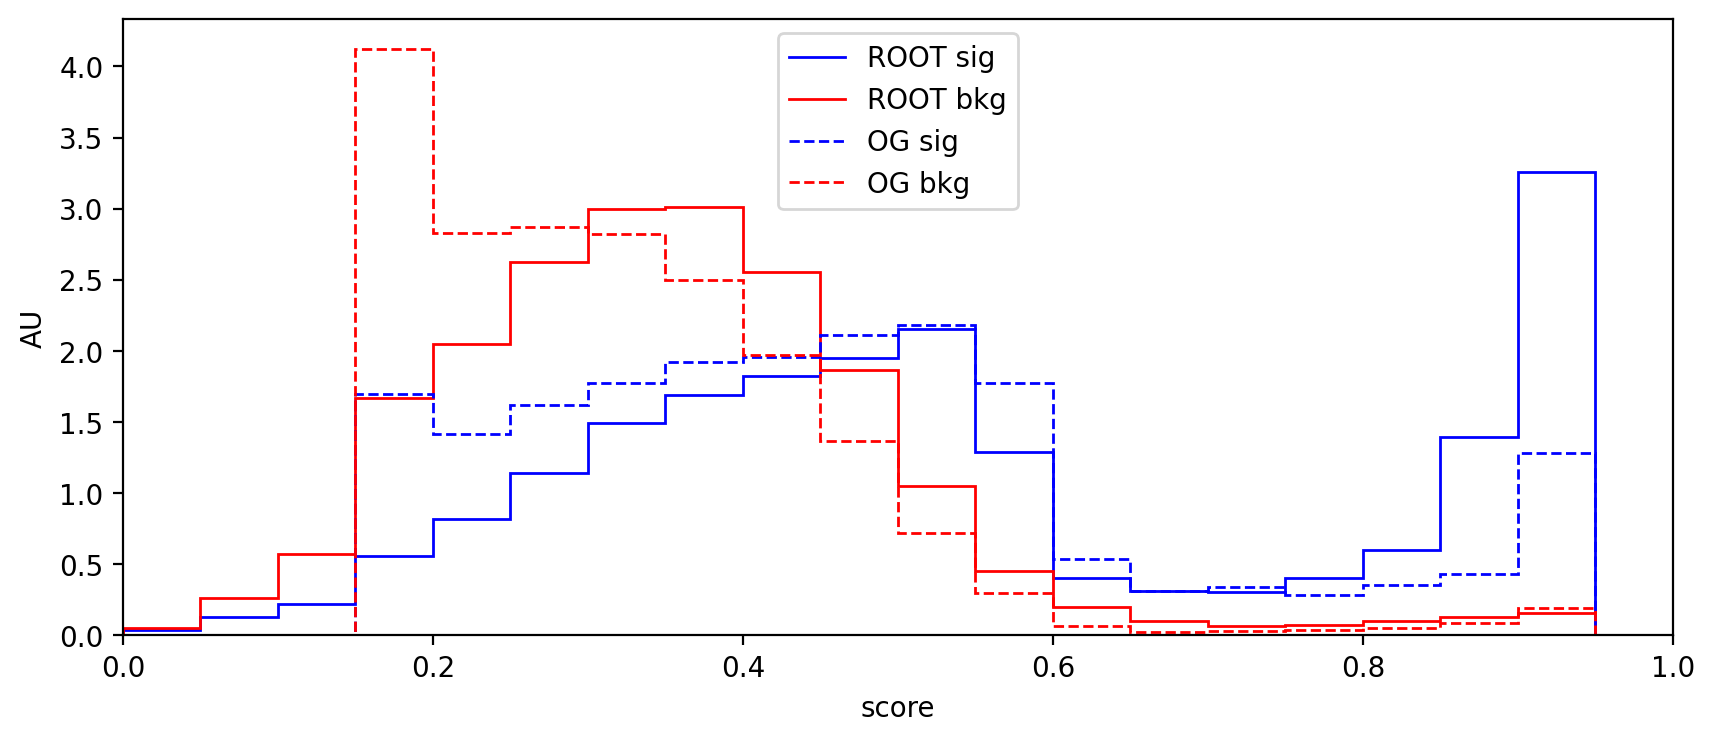

In [10]:
bin_edges = np.arange(0, 1, 0.05)

plt.figure(figsize=(10, 4), dpi=200)

# ROOT predictions
hist_root_sig, _ = np.histogram(ak.flatten(root_predictions['signal']), bins=bin_edges, density=True)
plt.stairs(hist_root_sig, bin_edges, label=f"ROOT sig", color=f"blue")

hist_root_bkg, _ = np.histogram(ak.flatten(root_predictions['background']), bins=bin_edges, density=True)
plt.stairs(hist_root_bkg, bin_edges, label=f"ROOT bkg", color=f"red")

# OG predictions
hist_og_sig, _ = np.histogram(ak.flatten(og_predictions['signal']), bins=bin_edges, density=True)
plt.stairs(hist_og_sig, bin_edges, label=f"OG sig", linestyle="--", color=f"blue")

hist_og_bkg, _ = np.histogram(ak.flatten(og_predictions['background']), bins=bin_edges, density=True)
plt.stairs(hist_og_bkg, bin_edges, label=f"OG bkg", linestyle="--", color=f"red")

plt.xlabel("score")
plt.ylabel('AU')
plt.xlim(0,1)
plt.legend()
plt.show()

ValueError: x and y must have same first dimension, but have shapes (27,) and (45,)

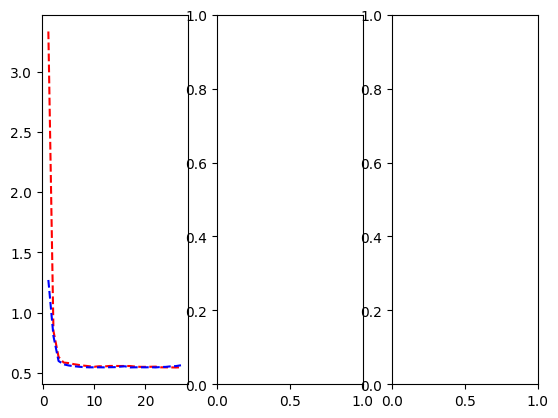

In [11]:
# Loss Curves

original_training_losses_8 = [3.333814859390259, 0.8479753732681274, 0.6327973008155823, 0.5856683850288391, 0.581212043762207, 0.5721426010131836, 0.5657449960708618, 0.5600014925003052, 0.5552849769592285, 0.5508038997650146, 0.5550783276557922, 0.5532186627388, 0.5573946833610535, 0.5575675964355469, 0.5569628477096558, 0.557162344455719, 0.556764543056488, 0.5523778200149536, 0.5501466989517212, 0.5500723123550415, 0.5506507158279419, 0.5518348217010498, 0.5460847616195679, 0.5457041263580322, 0.5454825758934021, 0.5447657108306885, 0.5463917851448059]
original_validation_losses_8 = [1.2713254690170288, 0.8051267266273499, 0.598760187625885, 0.5708408355712891, 0.5612977743148804, 0.5553808808326721, 0.5508555769920349, 0.5474780201911926, 0.5459796786308289, 0.5460736751556396, 0.5461593270301819, 0.5458468198776245, 0.5468762516975403, 0.5474416017532349, 0.551364541053772, 0.5546722412109375, 0.5450754165649414, 0.5461377501487732, 0.546296238899231, 0.5459293723106384, 0.546898365020752, 0.5453064441680908, 0.5485796928405762, 0.5497077703475952, 0.554289698600769, 0.556311309337616, 0.563164472579956]
root_training_losses_8 = [6.66945743560791, 4.376375198364258, 2.7720401287078857, 1.7300633192062378, 1.2300329208374023, 1.0391563177108765, 0.8911680579185486, 0.7978253364562988, 0.7344653010368347, 0.6664237976074219, 0.636656641960144, 0.6241737604141235, 0.6062090396881104, 0.6010542511940002, 0.5932687520980835, 0.6058300137519836, 0.6041695475578308, 0.5974020957946777, 0.5937110185623169, 0.5924699902534485, 0.5866457223892212, 0.580976128578186, 0.573573648929596, 0.571016252040863, 0.5743123888969421, 0.5641528367996216, 0.5622111558914185, 0.5591949820518494, 0.5609409213066101, 0.5591098070144653, 0.5545949935913086, 0.5619792342185974, 0.5472315549850464, 0.5487379431724548, 0.5487625598907471, 0.5459560751914978, 0.5441777110099792, 0.541507363319397, 0.5389420986175537, 0.5439608693122864, 0.5392481684684753, 0.5398896336555481, 0.5321760773658752, 0.5350943803787231, 0.5383622646331787]
root_validation_losses_8 = [5.487383842468262, 3.8544857501983643, 2.360546350479126, 1.6768550872802734, 1.3341097831726074, 1.1460349559783936, 0.9804929494857788, 0.8997026085853577, 0.8309943675994873, 0.7261307239532471, 0.6949489116668701, 0.6664369106292725, 0.6655059456825256, 0.6492233276367188, 0.6398873329162598, 0.6957287788391113, 0.6946043372154236, 0.6016758680343628, 0.600351095199585, 0.5939167141914368, 0.5858524441719055, 0.585443913936615, 0.6713149547576904, 0.5761643648147583, 0.5732468962669373, 0.6454808712005615, 0.6486896872520447, 0.5764307975769043, 0.6289635896682739, 0.6523072719573975, 0.563301682472229, 0.5620145201683044, 0.5611209869384766, 0.5606638789176941, 0.5600605010986328, 0.5589403510093689, 0.6257568597793579, 0.55817049741745, 0.5584855079650879, 0.5580574870109558, 0.5572715401649475, 0.5580240488052368, 0.5586236119270325, 0.5575692653656006, 0.562904953956604]

original_training_losses_64 =  [7.544331073760986, 5.13128137588501, 3.464021682739258, 2.2522125244140625, 1.5747401714324951, 1.256024718284607, 1.0468424558639526, 0.8984960913658142, 0.7801864147186279, 0.7353963255882263, 0.7069629430770874, 0.6804150938987732, 0.6450843214988708, 0.6175830960273743, 0.6052219867706299, 0.5976365804672241, 0.591192364692688, 0.5835461020469666, 0.5845446586608887, 0.5829890370368958, 0.5810961723327637, 0.5796206593513489, 0.5785620212554932, 0.5777168869972229, 0.5784944295883179, 0.5756633281707764, 0.5710373520851135, 0.5647143721580505, 0.5647940635681152, 0.5638916492462158, 0.561351478099823, 0.5659613013267517, 0.5581061244010925, 0.5606012344360352, 0.5626909136772156, 0.5596814751625061, 0.5589358806610107, 0.5552962422370911, 0.554761528968811, 0.5489538908004761, 0.553676962852478, 0.5489346981048584, 0.5512722730636597, 0.5474149584770203, 0.5493199825286865]
original_validation_losses_64 = [6.149656772613525, 4.390331268310547, 2.894622802734375, 1.944467306137085, 1.4404031038284302, 1.1931484937667847, 1.05070161819458, 0.8648874759674072, 0.789232075214386, 0.7404322028160095, 0.7098050713539124, 0.6503070592880249, 0.6302317976951599, 0.619067370891571, 0.6049804091453552, 0.6027827262878418, 0.5866126418113708, 0.6880714297294617, 0.5759516954421997, 0.5736985802650452, 0.5724205374717712, 0.5711190700531006, 0.5692535638809204, 0.5631364583969116, 0.5594165325164795, 0.5579753518104553, 0.556144654750824, 0.5556015968322754, 0.5563036203384399, 0.645733118057251, 0.5525426268577576, 0.5512256026268005, 0.550409197807312, 0.5503184199333191, 0.5488414764404297, 0.5526849031448364, 0.547883152961731, 0.5466964244842529, 0.5483920574188232, 0.5463583469390869, 0.5475722551345825, 0.5447495579719543, 0.54731285572052, 0.5430155396461487, 0.5426459312438965]
root_training_losses_64 = []
root_validation_losses_64 = []

original_training_losses_512 = [8.942265510559082, 8.391587257385254, 7.993427276611328, 7.663282871246338, 7.299986362457275, 6.865237712860107, 6.5076446533203125, 6.314448356628418, 5.921805381774902, 5.7007341384887695, 5.319620132446289, 5.194584846496582, 4.888476371765137, 4.719005584716797, 4.236448764801025, 4.145458221435547, 4.011999130249023, 3.7435147762298584, 3.5396926403045654, 3.13637638092041, 3.065049409866333, 3.035507917404175, 2.9131200313568115, 2.6185247898101807, 2.2993409633636475, 2.1554222106933594, 2.1329493522644043, 2.0842320919036865, 2.0033059120178223, 1.9741066694259644, 1.7588411569595337, 1.5695468187332153, 1.5680410861968994, 1.5296975374221802, 1.4379295110702515, 1.4132142066955566, 1.3713948726654053, 1.3493832349777222, 1.312313199043274, 1.286101222038269, 1.2706091403961182, 1.1938776969909668, 1.1226948499679565, 1.1006124019622803, 1.0962119102478027]
original_validation_losses_512 = [9.11207389831543, 8.18625259399414, 8.097168922424316, 7.493468761444092, 7.466040134429932, 6.7380523681640625, 6.670027256011963, 6.158333778381348, 6.090157508850098, 5.549251556396484, 5.445863246917725, 5.322861671447754, 4.8937177658081055, 4.862618923187256, 4.316166877746582, 4.179376602172852, 4.109939098358154, 3.779646873474121, 3.3193161487579346, 3.2309658527374268, 3.1594364643096924, 3.084493637084961, 2.778907060623169, 2.6795802116394043, 2.292837142944336, 2.2297608852386475, 2.2154183387756348, 2.1348509788513184, 2.0646042823791504, 2.0456552505493164, 1.6398987770080566, 1.6369200944900513, 1.6332061290740967, 1.5000571012496948, 1.4996764659881592, 1.4265490770339966, 1.4265490770339966, 1.366784691810608, 1.3654612302780151, 1.3196433782577515, 1.319389820098877, 1.2036900520324707, 1.1422454118728638, 1.1344444751739502, 1.1344444751739502]
root_training_losses_512 = []
root_validation_losses_512 = []


epochs = [i+1 for i in range(len(original_training_losses_8))]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3)
for i in range(3):
    if i == 0:
        ax = ax1
        original_training_losses = original_training_losses_8
        original_validation_losses = original_validation_losses_8
        root_training_losses = root_training_losses_8
        root_validation_losses = root_validation_losses_8
    elif i == 1:
        ax = ax2
        original_training_losses = original_training_losses_64
        original_validation_losses = original_validation_losses_64
        root_training_losses = root_training_losses_64
        root_validation_losses = root_validation_losses_64
    else:
        ax = ax3
        original_training_losses = original_training_losses_512
        original_validation_losses = original_validation_losses_512
        root_training_losses = root_training_losses_512
        root_validation_losses = root_validation_losses_512

    ax.plot(epochs, original_training_losses, linestyle="--", color="red", label="Original training loss")
    ax.plot(epochs, original_validation_losses, linestyle="--", color="blue", label="Original validation loss")
    ax.plot(epochs, root_training_losses, color="red", label="ROOT training loss")
    ax.plot(epochs, root_validation_losses, color="blue", label="ROOT validation loss")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()


Text(0.5, 1.0, 'ROOT starts off slower, but generally has faster times following')

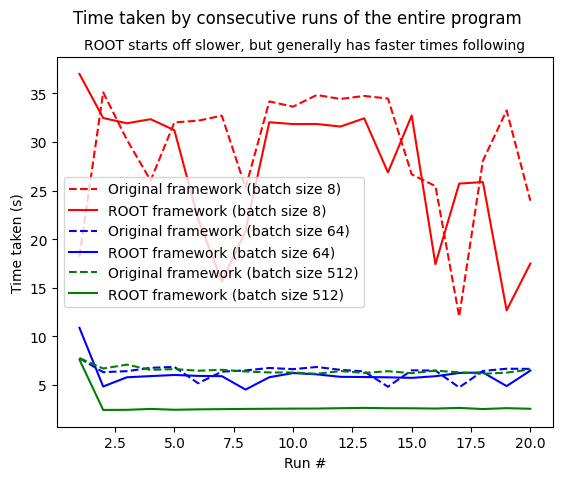

In [12]:
# Running time by full run
OG_times_8 = [18.217554847999963, 35.10303537500022, 30.22488824500033, 26.03042426200045, 32.012684547999925, 32.18879812799969, 32.705260507000276, 25.28929417800009, 34.17357040299976, 33.63265970999964, 34.831941707000624, 34.42431241400027, 34.73547585600045, 34.46626156000002, 26.669822284000475, 25.4650105540004, 12.05536310700063, 28.07052494399977, 33.2469511219997, 23.958240219999425]
ROOT_times_8 = [37.00000027399983, 32.46532185900014, 31.92515576200003, 32.34375574400019, 31.21462568900006, 22.096546685999783, 15.667698282999481, 20.859121804000097, 32.03134494300048, 31.843139296999652, 31.847926070999165, 31.588485467999817, 32.435116854000626, 26.868761921999976, 32.726791162000154, 17.433677372999227, 25.7213184430002, 25.879813255000045, 12.686950858000273, 17.496149323999816]
OG_times_64 = [7.7606911240000045, 6.328885055001592, 6.432313418001286, 6.77238779199979, 6.873176018001686, 5.191365967999445, 6.379302066001401, 6.50743089900061, 6.762794419999409, 6.638553699998738, 6.861707836000278, 6.5653272709969315, 6.4065702959997, 4.830777068000316, 6.5169723620019795, 6.493954183999449, 4.758938109000155, 6.452757003000443, 6.682255222000094, 6.667404503998114]
ROOT_times_64 = [10.885322205002012, 4.852821467000467, 5.803312364001613, 5.92307799700211, 6.042248494999512, 5.94430633400043, 5.918981923998217, 4.538530252000783, 5.807647634999739, 6.237439569998969, 6.102168620996963, 5.849660306997976, 5.828734317001363, 5.799854127002618, 5.742596306998166, 5.910338092002348, 6.245182534999913, 6.3021512430022995, 4.896772023999802, 6.487986610998632]
OG_times_512 = [7.774660433999998, 6.702676476999841, 7.106013607000023, 6.560485271000289, 6.647254417999648, 6.4752353799995035, 6.572923020000417, 6.399092357999507, 6.299386474999665, 6.293127363999702, 6.161980588000006, 6.441816929000197, 6.2544632130002356, 6.428924928000015, 6.223730284999874, 6.481273185999271, 6.315779327999735, 6.161297788000411, 6.279403555000499, 6.61099890999958]
ROOT_times_512 = [7.621526077000453, 2.446112087000074, 2.4558445760012546, 2.549053766000725, 2.462882255000295, 2.506019516999004, 2.5276358679984696, 2.5486542470007407, 2.56475263700122, 2.5806953249993967, 2.5853527229992324, 2.625491605998832, 2.655203297999833, 2.6215864259993396, 2.6148749589992804, 2.5862292460005847, 2.654225584999949, 2.5370477470005426, 2.6292919179995806, 2.562279531999593]

runs = [i+1 for i in range(len(ROOT_times_64))]

fig = plt.figure()
ax = plt.axes()
ax.plot(runs, OG_times_8, linestyle="--", color="red", label="Original framework (batch size 8)")
ax.plot(runs, ROOT_times_8, color="red", label="ROOT framework (batch size 8)")
ax.plot(runs, OG_times_64, linestyle="--", color="blue", label="Original framework (batch size 64)")
ax.plot(runs, ROOT_times_64, color="blue", label="ROOT framework (batch size 64)")
ax.plot(runs, OG_times_512, linestyle="--", color="green", label="Original framework (batch size 512)")
ax.plot(runs, ROOT_times_512, color="green", label="ROOT framework (batch size 512)")



plt.xlabel("Run #")
plt.ylabel("Time taken (s)")
plt.legend()
plt.suptitle("Time taken by consecutive runs of the entire program", fontsize=12)
plt.title("ROOT starts off slower, but generally has faster times following", fontsize=10)

Text(0.5, 1.0, 'The first batch is significantly slower, and large batches are slightly slower.')

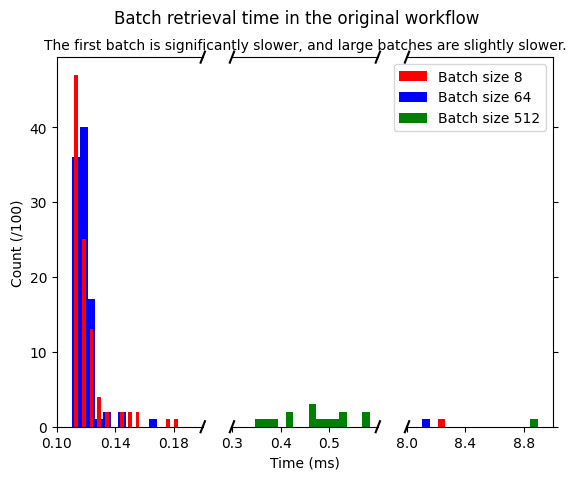

In [13]:
OG_8 = [0.008215150999603793, 0.0001837739982875064, 0.00014568299957318231, 0.00012719900041702203, 0.00012566599980345927, 0.00012409199916874059, 0.00013280900020617992, 0.00012444300227798522, 0.0001223699982801918, 0.00012056600098730996, 0.00012110700117773376, 0.00011807099872385152, 0.00011814200115622953, 0.00011801099753938615, 0.00012669700299738906, 0.00012381199849187396, 0.00011728000026778318, 0.000117480998596875, 0.000116868999612052, 0.00011452400212874636, 0.0001147559996752534, 0.00011313199865981005, 0.00011313200229778886, 0.00012655699902097695, 0.00011386299956939183, 0.00011373400047887117, 0.00011475499923108146, 0.00011640799857559614, 0.00011410400111344643, 0.00011640800221357495, 0.00011473499762360007, 0.00012244000026839785, 0.00011778000043705106, 0.00011729000107152387, 0.00011464499766589142, 0.00011419400107115507, 0.00011518600149429403, 0.00011641899982350878, 0.0001140729982580524, 0.00011559700215002522, 0.00012514499758253805, 0.00011591700240387581, 0.00011642800018307753, 0.00011498599997139536, 0.00011400299990782514, 0.00011355300011928193, 0.00011358299889252521, 0.00015561200052616186, 0.00013219799802755006, 0.0001193530006275978, 0.0001165389985544607, 0.00011690900282701477, 0.00011416399865993299, 0.00011465499846963212, 0.00011417400310165249, 0.00011348299813107587, 0.00011447500219219364, 0.00012725799751933664, 0.00011461500253062695, 0.00011475499923108146, 0.00011581699800444767, 0.0001539290024084039, 0.00014630399891757406, 0.00012148799942224286, 0.00012281000090297312, 0.00012071599849150516, 0.00011541700223460793, 0.00011543599975993857, 0.0001153960001829546, 0.00011460499808890745, 0.0001143039989983663, 0.00011364400052116252, 0.00011377299961168319, 0.00011916299990843982, 0.0001746380003169179, 0.00011707900193869136, 0.0001150659991253633, 0.00011570700007723644, 0.00011509500109241344, 0.00011428499783505686, 0.0001514430005045142, 0.00014883900075801648, 0.0001226700005645398, 0.00011585799802560359, 0.00011505500151542947, 0.00011553700096555986, 0.00011524599904078059, 0.00011514599827933125, 0.00011515600272105075, 0.00012379200052237138, 0.000117559997306671, 0.00011674900088110007, 0.00011418400026741438, 0.00011466499927337281, 0.00011384300159988925, 0.00011409400030970573, 0.00011480499961180612, 0.00011426499986555427, 0.0001237619981111493, 0.00011591700240387581]
OG_64 = [0.00810972299950663, 0.0001471959985792637, 0.00013675599984708242, 0.00012806000086129643, 0.00012362199777271599, 0.0001432290009688586, 0.00013345000115805306, 0.00012441299986676313, 0.0001214279982377775, 0.00011872200047946535, 0.0001259560012840666, 0.00012283099931664765, 0.00011910299872397445, 0.00011989500126219355, 0.00011951399937970564, 0.00012241900185472332, 0.00011799099956988357, 0.00011885300045832992, 0.00012371199773042463, 0.00012114700075471774, 0.00011814200115622953, 0.00011742000060621649, 0.00011671899846987799, 0.00011596699914662167, 0.00011812100274255499, 0.00011815199832199141, 0.00011495500075398013, 0.00012396300007821992, 0.00011836200064863078, 0.00011489499956951477, 0.00011389399878680706, 0.00011482500121928751, 0.00011487499796203338, 0.00011512600030982867, 0.00011497599916765466, 0.00012232900189701468, 0.00011767099931603298, 0.00011635800183285028, 0.00011673900007735938, 0.00011601699952734634, 0.00011485499999253079, 0.00011497599916765466, 0.00011431399980210699, 0.00011555699893506244, 0.00012349100143183023, 0.0001170899995486252, 0.00011471499965409748, 0.0001153960001829546, 0.00011435499982326292, 0.00011600699872360565, 0.00011472500045783818, 0.0001165590001619421, 0.0001166990005003754, 0.00012420200073393062, 0.00011642900062724948, 0.00011542599895619787, 0.00011559700215002522, 0.00011636799899861217, 0.00011584700041566975, 0.00011574699965422042, 0.0001146850008808542, 0.00012156799857621081, 0.00011805100075434893, 0.00011505599832162261, 0.00011623799946391955, 0.00011419400107115507, 0.00011510599870234728, 0.0001152460026787594, 0.00011534599980222993, 0.0001152359982370399, 0.00012185800005681813, 0.00011552700016181916, 0.00011712899868143722, 0.00011591800284804776, 0.00016721299834898673, 0.0001190330003737472, 0.00011581700164242648, 0.0001177809972432442, 0.0001249939996341709, 0.00011801200162153691, 0.00011692900079651736, 0.00011869199806824327, 0.00011688000085996464, 0.000115916998765897, 0.00011590700160013512, 0.00011515599908307195, 0.00012145800064899959, 0.00011777100007748231, 0.00011389299834263511, 0.00011721000191755593, 0.00011491500117699616, 0.00011568699846975505, 0.00011553700096555986, 0.00011619699944276363, 0.00011354299931554124, 0.00012244000026839785, 0.00011555599849089049, 0.00011461500253062695, 0.00011335299859638326, 0.00011377299961168319]
OG_512 = [0.008885788000043249, 0.0004208189966448117, 0.00046711500181118026, 0.00041642100040917285, 0.0005064590004622005, 0.0004805209973710589, 0.00038517200300702825, 0.0005688459968951065, 0.0005212780015426688, 0.0004607029986800626, 0.00036441400152398273, 0.0005758789993706159, 0.0004903789995296393, 0.0003554070026439149, 0.00047167399679892696, 0.0005271080008242279]
# Note that the 512 version can't be very high because not enough events :(

OG_8 = [t*1000 for t in OG_8]
OG_64 = [t*1000 for t in OG_64]
OG_512 = [t*1000 for t in OG_512]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, sharey=True)


ax1.set_xlim(0.1, 0.2)
ax2.set_xlim(0.3, 0.6)
ax3.set_xlim(8, 9)
ax1.set_xticks(np.arange(0.1, 0.2, 0.04))
ax2.set_xticks(np.arange(0.3, 0.6, 0.1))
ax3.set_xticks(np.arange(8, 9, 0.4))

ax1_bins = np.linspace(0.1, 0.2, 20)
ax2_bins = np.linspace(0.3, 0.6, 20)
ax3_bins = np.linspace(8, 9, 20)

ax1.spines["right"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.spines["left"].set_visible(False)
ax3.spines["left"].set_visible(False)
ax1.yaxis.tick_left()
ax2.yaxis.set_visible(False)
ax3.yaxis.tick_right()


ax1.hist(OG_64, color="blue", bins=ax1_bins)
ax2.hist(OG_64, color="blue", bins=ax2_bins)
ax3.hist(OG_64, color="blue", label="Batch size 64", bins=ax3_bins)
ax1.hist(OG_8, color="red", bins=ax1_bins, rwidth=0.5)
ax2.hist(OG_8, color="red", bins=ax2_bins)
ax3.hist(OG_8, color="red", label="Batch size 8", bins=ax3_bins)
ax1.hist(OG_512, color="green", bins=ax1_bins)
ax2.hist(OG_512, color="green", bins=ax2_bins)
ax3.hist(OG_512, color="green", label="Batch size 512", bins=ax3_bins)

d = .015 
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((1-d, 1+d), (-d, +d), **kwargs)
ax1.plot((1-d, 1+d), (1-d, 1+d), **kwargs)

kwargs.update(transform=ax2.transAxes)
ax2.plot((-d, +d), (1-d, 1+d), **kwargs)
ax2.plot((-d, +d), (-d, +d), **kwargs)
ax2.plot((1-d, 1+d), (-d, +d), **kwargs)
ax2.plot((1-d, 1+d), (1-d, 1+d), **kwargs)

kwargs.update(transform=ax3.transAxes)
ax3.plot((-d, +d), (1-d, 1+d), **kwargs)
ax3.plot((-d, +d), (-d, +d), **kwargs)


handles, labels = plt.gca().get_legend_handles_labels()
order = [1, 0, 2]
plt.legend([handles[idx] for idx in order],[labels[idx] for idx in order])
plt.sca(ax1)
plt.ylabel("Count (/100)")
plt.sca(ax2)
plt.xlabel("Time (ms)")
plt.suptitle("Batch retrieval time in the original workflow", fontsize=12)
plt.title("The first batch is significantly slower, and large batches are slightly slower.", fontsize=10)

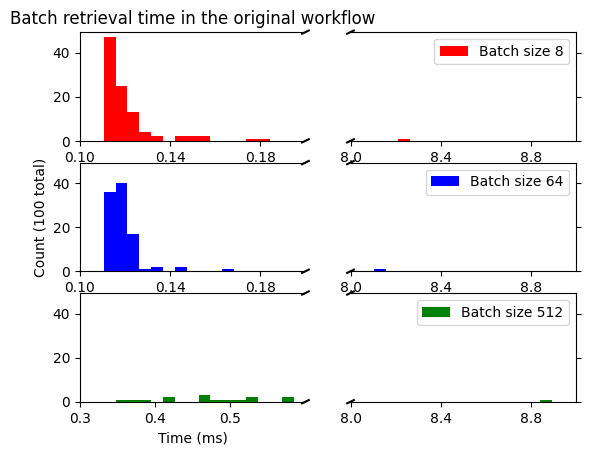

In [16]:
fig, axes = plt.subplots(3, 2, sharey=True)
ax1, ax3 = axes[0]
ax1.set_xlim(0.1, 0.2)
ax3.set_xlim(8, 9)
ax1.set_xticks(np.arange(0.1, 0.2, 0.04))
ax3.set_xticks(np.arange(8, 9, 0.4))
ax1_bins = np.linspace(0.1, 0.2, 20)
ax3_bins = np.linspace(8, 9, 20)
ax1.spines["right"].set_visible(False)
ax3.spines["left"].set_visible(False)
ax1.yaxis.tick_left()
ax3.yaxis.tick_right()
ax1.hist(OG_8, color="red", label="Batch size 8", bins=ax1_bins)
ax3.hist(OG_8, color="red", label="Batch size 8", bins=ax3_bins)
d = .015 
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((1-d, 1+d), (-d, +d), **kwargs)
ax1.plot((1-d, 1+d), (1-d, 1+d), **kwargs)
kwargs.update(transform=ax3.transAxes)
ax3.plot((-d, +d), (1-d, 1+d), **kwargs)
ax3.plot((-d, +d), (-d, +d), **kwargs)
plt.sca(ax1)
plt.title("Batch retrieval time in the original workflow")
plt.sca(ax3)
plt.legend()
# plt.ylabel("Count (/100)")
# plt.xlabel("Time (ms)")

ax1, ax3 = axes[1]
ax1.set_xlim(0.1, 0.2)
ax3.set_xlim(8, 9)
ax1.set_xticks(np.arange(0.1, 0.2, 0.04))
ax3.set_xticks(np.arange(8, 9, 0.4))
ax1_bins = np.linspace(0.1, 0.2, 20)
ax3_bins = np.linspace(8, 9, 20)
ax1.spines["right"].set_visible(False)
ax3.spines["left"].set_visible(False)
ax1.yaxis.tick_left()
ax3.yaxis.tick_right()
ax1.hist(OG_64, color="blue", label="Batch size 64", bins=ax1_bins)
ax3.hist(OG_64, color="blue", label="Batch size 64", bins=ax3_bins)
d = .015 
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((1-d, 1+d), (-d, +d), **kwargs)
ax1.plot((1-d, 1+d), (1-d, 1+d), **kwargs)
kwargs.update(transform=ax3.transAxes)
ax3.plot((-d, +d), (1-d, 1+d), **kwargs)
ax3.plot((-d, +d), (-d, +d), **kwargs)
plt.sca(ax1)
plt.ylabel("Count (100 total)")
plt.sca(ax3)
plt.legend()
# plt.xlabel("Time (ms)")

ax2, ax3 = axes[2]
ax2.set_xlim(0.3, 0.6)
ax3.set_xlim(8, 9)
ax2.set_xticks(np.arange(0.3, 0.6, 0.1))
ax3.set_xticks(np.arange(8, 9, 0.4))
ax2_bins = np.linspace(0.3, 0.6, 20)
ax3_bins = np.linspace(8, 9, 20)
ax2.spines["right"].set_visible(False)
ax3.spines["left"].set_visible(False)
ax2.yaxis.tick_left()
ax3.yaxis.tick_right()
ax2.hist(OG_512, color="green", label="Batch size 512", bins=ax2_bins)
ax3.hist(OG_512, color="green", label="Batch size 512", bins=ax3_bins)
d = .015 
kwargs = dict(transform=ax2.transAxes, color='k', clip_on=False)
ax2.plot((1-d, 1+d), (-d, +d), **kwargs)
ax2.plot((1-d, 1+d), (1-d, 1+d), **kwargs)
kwargs.update(transform=ax3.transAxes)
ax3.plot((-d, +d), (1-d, 1+d), **kwargs)
ax3.plot((-d, +d), (-d, +d), **kwargs)
plt.sca(ax2)
plt.xlabel("Time (ms)")
plt.sca(ax3)
plt.legend()
# plt.ylabel("Count (/100)")
# plt.xlabel("Time (ms)")

In [20]:
ROOT_8_2 = [1.1356855720005115, 0.007122114000594593, 0.0012515529997472186, 0.0010448159991938155, 0.0008205859994632192, 0.0009918770010699518, 0.0007298959990293952, 0.0007177040006354218, 0.0009674209995864658, 0.0009140710008068709, 0.0007816430006641895, 0.000727461998394574, 0.0008775330006756121, 0.0008465449991490459, 0.0008358850009244634, 0.0007951690004119882, 0.0008660509993205778, 0.0008482680004817666, 0.0008346029990207171, 0.0007170720000431174, 0.0008266479999292642, 0.000811439000244718, 0.0007010320005065296, 0.0006891600005474174, 0.0009965959998226026, 0.0008025320003071101, 0.0008225599995057564, 0.0006967039989831392, 0.0008518050017300993, 0.0008278799996332964, 0.0007789880000927951, 0.0007627479990333086, 0.0008346230006281985, 0.0007121229991753353, 0.0009111159997701179, 0.0008455130009679124, 0.0007037969990051351, 0.0007220520001283148, 0.0008122300005197758, 0.0007455859995388892, 0.0008238730006269179, 0.0008957169993664138, 0.000850201000503148, 0.000829684000564157, 0.0007375599998340476, 0.0008084439996309811, 0.0007076450001477497, 0.0006913439992786152, 0.0007413180010189535, 0.0008318469990626909, 0.0008264680000138469, 0.000746237001294503, 0.0007049289997667074, 0.0006978170004003914, 0.0008289009983855067, 0.0008563230003346689, 0.0007034869995550252, 0.000687518000631826, 0.0006909730000188574, 0.0008446610008832067, 0.0008351439992111409, 0.0007414680003421381, 0.0006928069997229613, 0.0008354439996764995, 0.0007170130011218134, 0.0007186149996414315, 0.0031154719999904046, 0.0015838849994906923, 0.0011109400002169423, 0.0008841660001053242, 0.000818512000478222, 0.000991265998891322, 0.000979743999778293, 0.0009833510011958424, 0.0008597999985795468, 0.0008695070009707706, 0.0008787659990048269, 0.0009720090001792414, 0.0008061389999056701, 0.0009871480015135603, 0.0009585349998815218, 0.0009549879996484378, 0.0009810359988478012, 0.0009590560002834536, 0.0009179980006592814, 0.0009808869999687886, 0.0009416630000487203, 0.0009470530003454769, 0.0010232650001853472, 0.0009907650000968715, 0.0009707969984447118, 0.0010401880008430453, 0.0011659020001388853, 0.0008744980004848912, 0.0007868229986343067, 0.0007245659999171039, 0.0009248120004485827, 0.0009467920008319197, 0.0007692799990763888, 0.0007118129997252254]
ROOT_64_2 = [1.117454381999778, 0.007128184999601217, 0.0009504090012342203, 0.0009436969994567335, 0.0008795760004431941, 0.0009918369996739784, 0.0010024669991253177, 0.000981978000709205, 0.0009375249992444878, 0.000864669000293361, 0.0009582340007909806, 0.0009222770004271297, 0.0009033909991558176, 0.0008780640000622952, 0.0008711610007594572, 0.0008378579987038393, 0.0008667430010973476, 0.0007712829992669867, 0.0008913889996620128, 0.0007303880011022557, 0.0008584970000811154, 0.0009290589987358544, 0.0009181790010188706, 0.0008867099986673566, 0.0007803910011716653, 0.0008884839990059845, 0.0008148050001182128, 0.0007306980005523656, 0.0007320109998545377, 0.0007395039992843522, 0.000738232000003336, 0.0008715210005902918, 0.0008513539996783948, 0.0008597000014560763, 0.0009892919988487847, 0.0007711729995207861, 0.0007337140013987664, 0.0007214010001916904, 0.0007321799985220423, 0.0008556320008210605, 0.0008508529990649549, 0.0007429310007864842, 0.0008800180003163405, 0.0008382590003748192, 0.0008244429991464131, 0.000864649000504869, 0.0008774519992584828, 0.0007980749996931991, 0.0008467550014756853, 0.0008080629995674826, 0.0008698879992152797, 0.0007464379996235948, 0.0008377780013688607, 0.0007921830001578201, 0.0007535709992225748, 0.0008933320004871348, 0.0007489130002795719, 0.0008813999993435573, 0.0006990679994487436, 0.0008572850001655752, 0.0008917899995140033, 0.0007459160005964804, 0.0008716619995539077, 0.0008354940000572242, 0.0008888240008673165, 0.0009381959989696043, 0.0007808820009813644, 0.0008324589998665033, 0.0007809620001353323, 0.0007898690000729403, 0.0008566430005885195, 0.0008696589993633097, 0.0008296529995277524, 0.000872774000526988, 0.0007428200005961116, 0.0009134499996434897, 0.001210145999721135, 0.0009427349996258272, 0.0009156539999821689, 0.0007824750009604031, 0.0008317069987242576, 0.0008844559997669421, 0.0008575749998271931, 0.0008875020012055757, 0.0008874209997884464, 0.0007439630007866072, 0.0007210699986899272, 0.0008101969997369451, 0.0007174630009103566, 0.0007625569996889681, 0.0008617029998276848, 0.0009277570006815949, 0.0007864029994379962, 0.0007408670007862383, 0.00085161399874778, 0.0008779030013101874, 0.0008353939992957748, 0.0008499420000589453, 0.0008748469990678132, 0.0008480780015815981]
ROOT_512_2 = [1.1283058270000765, 0.0073012189986911835, 0.0014447950015892275, 0.001195467999423272, 0.001187513000331819, 0.0011996859993814724, 0.0009290689995395951, 0.0011390820000087842, 0.0008981520004454069, 0.001058290999935707, 0.0009333270008937689, 0.0011740479985746788, 0.0009121180009969976, 0.0008902169993234565, 0.0010489440010132967, 0.0017646830001467606]
ROOT_8_10 = [1.2309966350003378, 0.007246487000884372, 0.0010692619998735609, 0.0010391449995950097, 0.000827379000838846, 0.0009159849996649427, 0.0007465170001523802, 0.0008797069986030692, 0.0009578330009389902, 0.0008096759993350133, 0.0008443710012215888, 0.000844540998514276, 0.0007708230004936922, 0.0007677670000703074, 0.0007335440004681004, 0.000711882999894442, 0.0007310180008062162, 0.0009498279996478232, 0.0009533749998809071, 0.0008317369993164903, 0.000707995000993833, 0.0008797469999990426, 0.0010627299998304807, 0.000754953000068781, 0.0008093559990811627, 0.0009520020012132591, 0.0007742089983366895, 0.0007274020008480875, 0.000849971000207006, 0.0007427410000673262, 0.0008925909987738123, 0.0008896360013750382, 0.0009117059998970944, 0.0007925440004328266, 0.0012144829997851048, 0.0008270489997812547, 0.0008612519995949697, 0.0008603509995737113, 0.0007389530001091771, 0.000891839999894728, 0.0008608719999756431, 0.0008896050003386335, 0.0008372070005862042, 0.0008715219992154744, 0.0007142369995563058, 0.0007333930007007439, 0.0007183550005720463, 0.0008789249986875802, 0.000754893000703305, 0.0009398099991813069, 0.0009064070000022184, 0.0008862890008458635, 0.0007298159998754272, 0.0007194669997261371, 0.0008416860000579618, 0.0009036320006998722, 0.0010106119989359286, 0.00086918700071692, 0.0008576960008213064, 0.0008689070000400534, 0.0008536279983673012, 0.0008604100003140047, 0.0008520250012225006, 0.0008436399984930176, 0.0007897380000940757, 0.0008325489998242119, 0.0006812350002292078, 0.0008575160009058891, 0.0007884860006015515, 0.0009312629990745336, 0.0008783350003795931, 0.0007297359989024699, 0.0008388900005229516, 0.0007378120008070255, 0.0008544489992345916, 0.0008565429998270702, 0.0008503820008627372, 0.0007110019996616757, 0.0008221789994422579, 0.0007700509995629545, 0.000854280000567087, 0.0008408640005654888, 0.0008490700001857476, 0.0007139359986467753, 0.0008510030002071289, 0.0008269080008176388, 0.0009072390002984321, 0.0008588479995523812, 0.0008556020002288278, 0.0008720519999769749, 0.0007837869998184033, 0.0007563460003439104, 0.0007629789997736225, 0.0007118520006770268, 0.0006999709985393565, 0.000765533000958385, 0.0008136830001603812, 0.0007116130000213161, 0.0007295849991351133, 0.0008103270010906272]
ROOT_64_10 = [1.1212793419999798, 0.007310174998565344, 0.001170051000372041, 0.0010830669998540543, 0.0009707680001156405, 0.001014690000374685, 0.0008562019993405556, 0.0009652980006649159, 0.000897841000551125, 0.0009593759987183148, 0.0009602770005585626, 0.0009306320007453905, 0.000925012000152492, 0.0009439369987376267, 0.0008781540000200039, 0.0007509660008508945, 0.0008627150000393158, 0.0009279280002374435, 0.0008493099994666409, 0.0007988950001163175, 0.0008446009996987414, 0.0007484220004698727, 0.0007545819989900338, 0.0007246269997267518, 0.0008503820008627372, 0.0007248059991979972, 0.0007178840005508391, 0.0008145850006258115, 0.0007955000000947621, 0.0007862319998821476, 0.0007570369998575188, 0.0007558050001534866, 0.0007611949986312538, 0.000802763001047424, 0.0008876419997250196, 0.0007917019993328722, 0.0008846260006976081, 0.0008582970003772061, 0.0008561829999962356, 0.0008376280002266867, 0.0007755009992251871, 0.0007364690009126207, 0.0008659209997858852, 0.0008116600001812913, 0.0007637999988219235, 0.0007923829998617293, 0.000828962000014144, 0.0008810899998934474, 0.0008971490005933447, 0.0007572680005978327, 0.0007534609994763741, 0.0008885429997462779, 0.0007571380010631401, 0.0008831729992380133, 0.0008688960006111301, 0.0008599499997217208, 0.0008182719993783394, 0.0007162510009948164, 0.0007137459997466067, 0.0007400859994959319, 0.0007105000004230533, 0.0007237350000650622, 0.0007042279994493583, 0.0008783850007603178, 0.0007798099995852681, 0.0008526759993401356, 0.0008871110003383365, 0.0008752590001677163, 0.0008877309992385563, 0.0008744269998715026, 0.0007570580000901828, 0.0008305640003527515, 0.0009480850003455998, 0.0007707330005359836, 0.0008092249991022982, 0.0008610519998910604, 0.0008279200010292698, 0.0007620469987159595, 0.000780020000092918, 0.0008211479998863069, 0.000852736000524601, 0.0007500740011892049, 0.0008939339986682171, 0.0007645910009159707, 0.0008829130001686281, 0.000815636998595437, 0.0008814500015432714, 0.000853156998346094, 0.0007777160008117789, 0.0007524089996877592, 0.0007974230011313921, 0.0007988649995240849, 0.000775753000198165, 0.0008922699998947792, 0.0009423139999853447, 0.0007884459992055781, 0.000777256000219495, 0.0008219880000979174, 0.0009555289998388616, 0.0008383389995287871]
ROOT_512_10 = [1.1377344279990211, 0.0075397950004116865, 0.0012331189991527935, 0.0010710950009524822, 0.0011124129996460397, 0.0011947759994654916, 0.0011283130006631836, 0.0011151769995194627, 0.0011737380009435583, 0.0011133839998365147, 0.0009922779991029529, 0.00105772000097204, 0.0010219830001005903, 0.000980315999186132, 0.0008949650000431575, 0.0018111610006599221]
ROOT_8_1000 = [1.114643991999401, 0.006934169001397095, 0.0012460749985621078, 0.0010214450012426823, 0.0008662639993417542, 0.000806711999757681, 0.0009301440004492179, 0.0009569939993525622, 0.0009481970009801444, 0.0007864349990995834, 0.0008501230004185345, 0.0008463670001219725, 0.0007212219989014557, 0.0008255080010712845, 0.0008117010002024472, 0.0007031179993646219, 0.0008067230010055937,0.0006948319987714058, 0.0007130570011213422, 0.0006952530002308777, 0.0006811269995523617, 0.0006829100002505584, 0.0008647710001241649, 0.0008015729999897303, 0.0007365099991147872, 0.0006893129993841285, 0.0008293240007333225, 0.0006849839992355555, 0.0008367790014744969, 0.0008421490001637721, 0.0008149469995260006, 0.0007273139999597333, 0.0008324499995069345, 0.0007558670004073065, 0.0007931170002848376, 0.0007041899989417288, 0.0008184850012185052, 0.0007115339994925307, 0.0006992099988565315, 0.0006969670012040297, 0.0006912459994055098, 0.0008180830009223428, 0.0007566280000901315, 0.0008294149993162137, 0.0007097210000210907, 0.0006856849995529046, 0.0008297260010294849, 0.0007176849994721124, 0.0006894920006743632, 0.00079714499952388, 0.000801662999947439, 0.0006967560002522077, 0.0006873989987070672, 0.0008169810007530032, 0.0007949999999254942, 0.0008805609995761188, 0.000858569001138676, 0.000707385999703547, 0.0008473489997413708, 0.0007863139999244595, 0.0008408260000578593, 0.0007737609994364902, 0.0007075260000419803, 0.0006955740009289002, 0.0007018659998720977, 0.0007171939996624133, 0.0007644529996468918, 0.0007696630000282312, 0.0008310180000989931, 0.000705763000951265, 0.0007124650001060218, 0.0008129339985316619, 0.0007571100013592513, 0.0007007829990470782, 0.0008318800009874394, 0.0007348469989665318,0.0007176859999162843, 0.0008351249998668209, 0.0007159420001698891, 0.0007501569998566993, 0.0006992500002525048, 0.0007121849994291551, 0.0006866480016469723, 0.0006961749986658106, 0.0008492320012010168, 0.0008016229985514656, 0.0008110100006888388, 0.0007190880005509825, 0.0007982059996720636, 0.0008263689996965695, 0.0008400650003750343, 0.0007555159991170513, 0.0007137980010156753, 0.0006964559997868491, 0.0006937309990462381, 0.0006891510001878487, 0.0008415780012001051, 0.0007148499989853008, 0.0008150579997163732, 0.0007284359999175649]
ROOT_64_1000 = [1.126930024000103, 0.007054714998957934, 0.001063192999936291, 0.0010017780005000532, 0.0008250869996118126, 0.0009542679999867687, 0.0009996540011343313, 0.001023007998810499, 0.0009635260012146318, 0.0009422269995411625, 0.0009281900001951726, 0.0008096069996099686, 0.0010224670004390646, 0.0007909729993116343, 0.0007662360003450885, 0.0008671060004417086, 0.0008492619999742601, 0.000761356999646523, 0.0007209909999801312, 0.0008344249999936437, 0.0009251339997717878, 0.0008998369994515087, 0.000824365000880789, 0.0008123930001602275, 0.0008743689995753812, 0.0009386100009578513, 0.0008282819999294588, 0.0009117399986280361, 0.0009520540006633382, 0.0008892070000001695, 0.0007525010005338117, 0.000822501999209635, 0.0008222910000768024, 0.0007369020004261984, 0.0008200669999496313, 0.0008704020001459867, 0.0008467269999528071, 0.0008714129999134457, 0.0008613449990662048, 0.0008547020006517414, 0.0007185670001490507, 0.0007016260005912045, 0.0007007529984548455, 0.0008714440009498503, 0.0008394340002269018, 0.0009712299997772789, 0.0007563479994132649, 0.0008815929995762417, 0.0008825240001897328, 0.0008585400009906152, 0.0007308200001716614, 0.000841696999486885, 0.00072567099959997, 0.0007252690011227969, 0.0008555939984944416, 0.0008268700003100093, 0.0008502640012011398, 0.0007221139985631453, 0.0008482700013701105, 0.0008567959994252305, 0.0008111909992294386, 0.0008259380010713357, 0.0007180960001278436, 0.0007254100000864128, 0.0007901110002421774, 0.0008965209999587387, 0.0007317019990296103, 0.0008377499998459825, 0.0008227819998865016, 0.0009046560007845983, 0.000868658999024774, 0.0007802730015100678, 0.0008496619993820786, 0.0008763929999986431, 0.0008820839993859408, 0.0007691310001973761, 0.0008813029999146238, 0.0007155210005294066, 0.0007407479988614796, 0.000788639001257252, 0.000854621999678784, 0.0008839769998303382, 0.0007234669992612908, 0.0007312300003832206, 0.0007393060004687868, 0.0008644209992780816, 0.000730128000213881, 0.0007130770009098342, 0.0007229650000226684, 0.0007189979987742845, 0.0006962150000617839, 0.0007573000002594199, 0.000843431000248529, 0.000716914000804536, 0.0008540109993191436, 0.0008533290001651039, 0.0008577490007155575, 0.0008546519984520273, 0.0009486080016358756, 0.0007075059984344989]
ROOT_512_1000 = [1.1231519310003932, 0.007330300999456085, 0.0013435490000119898, 0.0010023890008596936, 0.0009469249998801388, 0.0011133570005767979, 0.0009792059991013957, 0.0009089640007005073, 0.0008610539989604149, 0.001114630000301986, 0.0009609610006009461, 0.0009559619993524393, 0.0010781710006995127, 0.0009860690006462391, 0.0009681349984020926, 0.001744670000334736]
# Note that the 512 version can't be very high because not enough events :(


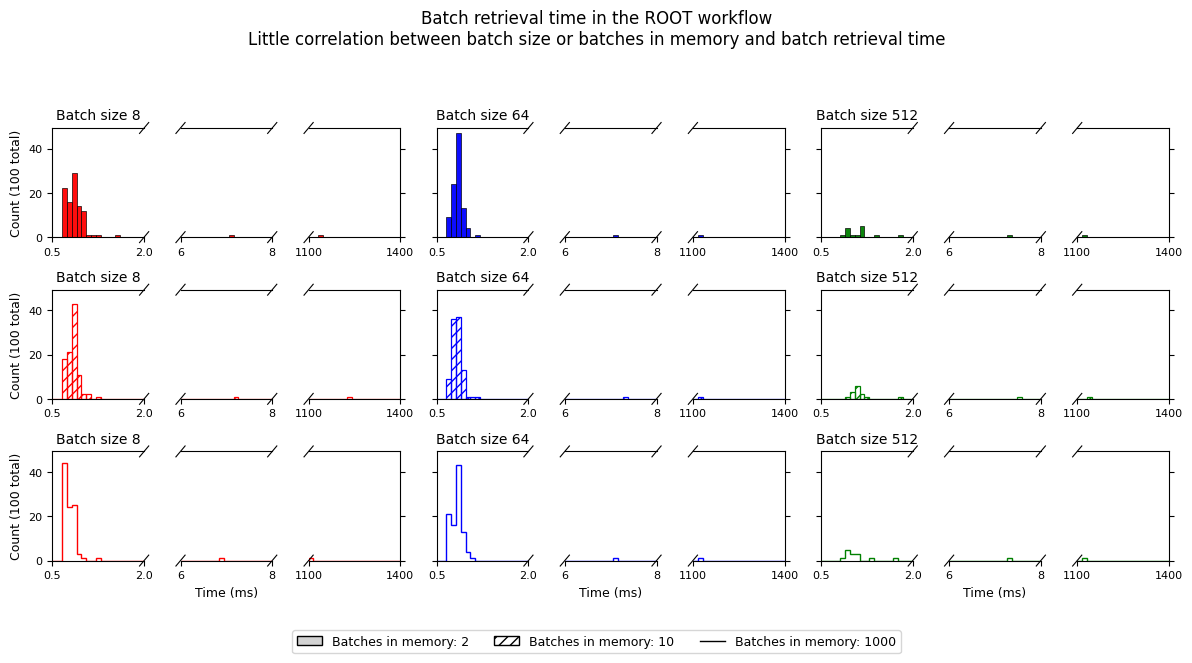

In [ ]:
import matplotlib as mpl
mpl.rcParams.update({
    'font.size': 9,
    'axes.titlesize': 10,
    'axes.labelsize': 9,
    'legend.fontsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'figure.titlesize': 12,
    'figure.dpi': 100,
})

# Apply a single *1000 scaling to convert seconds->ms where appropriate 
ROOT_8_2_ms = [t*1000 for t in ROOT_8_2] 
ROOT_64_2_ms = [t*1000 for t in ROOT_64_2] 
ROOT_512_2_ms = [t*1000 for t in ROOT_512_2] 
ROOT_8_10_ms = [t*1000 for t in ROOT_8_10] 
ROOT_64_10_ms = [t*1000 for t in ROOT_64_10] 
ROOT_512_10_ms = [t*1000 for t in ROOT_512_10] 
ROOT_8_1000_ms = [t*1000 for t in ROOT_8_1000] 
ROOT_64_1000_ms = [t*1000 for t in ROOT_64_1000] 
ROOT_512_1000_ms = [t*1000 for t in ROOT_512_1000] 

ROOT_GRID = [ 
    [ROOT_8_2_ms, ROOT_64_2_ms, ROOT_512_2_ms], 
    [ROOT_8_10_ms, ROOT_64_10_ms, ROOT_512_10_ms], 
    [ROOT_8_1000_ms, ROOT_64_1000_ms, ROOT_512_1000_ms] 
]


fig, axes = plt.subplots(3, 9, sharey=True, figsize=(12, 6.7))
fig.set_dpi(100)

batch_sizes = [8, 64, 512]
colors = ['red', 'blue', 'green']

range1 = (0.5, 2)
range2 = (6, 8)
range3 = (1100, 1400)
nbins = 20

for i in range(3):
    for j in range(3):
        ax1 = axes[i][3*j]
        ax2 = axes[i][3*j+1]
        ax3 = axes[i][3*j+2]

        data = np.array(ROOT_GRID[i][j])
        size = batch_sizes[j]
        color = colors[j]

        ax1_bins = np.linspace(range1[0], range1[1], nbins)
        ax2_bins = np.linspace(range2[0], range2[1], nbins)
        ax3_bins = np.linspace(range3[0], range3[1], nbins)

        d1 = data[(data >= range1[0]) & (data <= range1[1])]
        d2 = data[(data >= range2[0]) & (data <= range2[1])]
        d3 = data[(data >= range3[0]) & (data <= range3[1])]

        # Row-specific histogram styles
        if i == 0:
            # solid bars
            hist_kwargs = dict(
                color=color,
                histtype='bar',
                alpha=0.95,
                edgecolor='k',
                linewidth=0.5
            )
        elif i == 1:
            # hatched bars
            hist_kwargs = dict(
                facecolor='none',
                edgecolor=color,
                histtype='bar',
                hatch='///',
                linewidth=0.9
            )
        else:
            # step outline
            hist_kwargs = dict(
                color=color,
                histtype='step',
                linewidth=1.0
            )

        ax1.hist(d1, bins=ax1_bins, **hist_kwargs)
        ax2.hist(d2, bins=ax2_bins, **hist_kwargs)
        ax3.hist(d3, bins=ax3_bins, **hist_kwargs)

        ax1.set_xlim(*range1)
        ax2.set_xlim(*range2)
        ax3.set_xlim(*range3)

        ax1.set_xticks([range1[0], range1[1]])
        ax2.set_xticks([range2[0], range2[1]])
        ax3.set_xticks([range3[0], range3[1]])

        for ax in (ax1, ax2, ax3):
            ax.tick_params(axis='x', labelsize=8)
            ax.tick_params(axis='y', labelsize=8)

        ax1.spines['right'].set_visible(False)
        ax2.spines['right'].set_visible(False)
        ax2.spines['left'].set_visible(False)
        ax3.spines['left'].set_visible(False)

        ax1.yaxis.tick_left()
        ax2.yaxis.set_visible(False)
        ax3.yaxis.tick_right()

        d = .05
        kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False, linewidth=0.8)
        ax1.plot((1-d, 1+d), (-d, +d), **kwargs)
        ax1.plot((1-d, 1+d), (1-d, 1+d), **kwargs)

        kwargs.update(transform=ax2.transAxes)
        ax2.plot((-d, +d), (1-d, 1+d), **kwargs)
        ax2.plot((-d, +d), (-d, +d), **kwargs)
        ax2.plot((1-d, 1+d), (-d, +d), **kwargs)
        ax2.plot((1-d, 1+d), (1-d, 1+d), **kwargs)

        kwargs.update(transform=ax3.transAxes)
        ax3.plot((-d, +d), (1-d, 1+d), **kwargs)
        ax3.plot((-d, +d), (-d, +d), **kwargs)

        ax1.set_title(f"Batch size {size}", fontsize=10)

        if j == 0:
            ax1.set_ylabel('Count (100 total)', fontsize=9)

        # Add x-axis label to each of the 3 bottom broken-axis plots
        # Put it on the middle segment so it appears centered under each group
        if i == 2:
            ax2.set_xlabel("Time (ms)", fontsize=9, labelpad=4)
# create a single legend mapping histogram styles (rows) to batches-in-memory
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

legend_handles = [
    Patch(facecolor='lightgray', edgecolor='k'),
    Patch(facecolor='none', edgecolor='k', hatch='///'),
    Line2D([0], [0], color='k', linewidth=1.0)
]

legend_labels = [
    "Batches in memory: 2",
    "Batches in memory: 10",
    "Batches in memory: 1000"
]

fig.legend(
    legend_handles,
    legend_labels,
    loc='lower center',
    bbox_to_anchor=(0.5, 0.01),
    ncol=3,
    fontsize=9
)

fig.suptitle("Batch retrieval time in the ROOT workflow\n\
Little correlation between batch size or \
batches in memory and batch retrieval time", fontsize=12)

fig.tight_layout(rect=[0, 0.08, 1, 0.93])
# fig.savefig("root_batch_retrieval_time.png", dpi=300, bbox_inches="tight")

Text(0.5, 1.0, 'This is likely due to less batch loading overhead.')

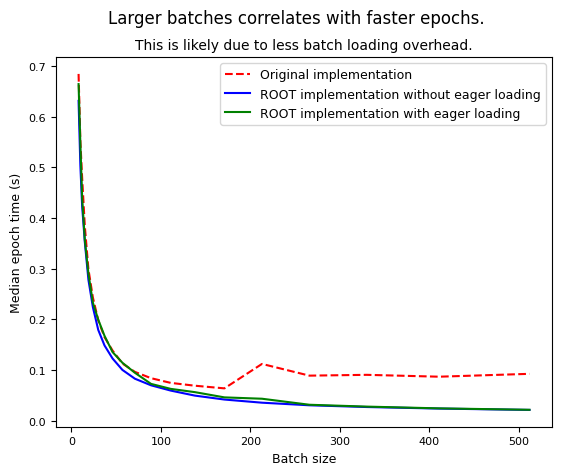

In [50]:
batch_sizes = np.round(np.geomspace(8, 512, 20))
OG_medians = [0.6846717810003611, 0.5524909539999499, 0.4792177250019449, 0.38373181100178044, 0.2992920120013878, 0.24344804949942045, 0.19840249799744925, 0.1651218949991744, 0.13871138900140068, 0.11313703199994052, 0.09660422199885943, 0.08417033399746288, 0.07489489799991134, 0.06932358500125702, 0.06407858300008229, 0.11231578200022341, 0.08918617499875836, 0.09078734799913946, 0.08709523700235877, 0.0927598449998186]
no_eager_loading_medians = [0.631536197501191, 0.5038218775007408, 0.4234843230005936, 0.35260398099853774, 0.278508799001429, 0.22432893400036846, 0.1794240204999369, 0.14875869000024977, 0.12300502700236393, 0.10049533799974597, 0.0830995010001061, 0.07012204000056954, 0.059678302000975236, 0.049770129000535235, 0.04202474100020481, 0.03579980600261479, 0.0306753539989586, 0.027256482000666438, 0.02419672299947706, 0.021529970999836223]
eager_loading_medians = [0.6645667844986747, 0.5469633734974195, 0.4399958819994936, 0.3568494130013278, 0.2906388190021971, 0.23303475750071811, 0.199595774498448, 0.16772186699745362, 0.13569969599848264, 0.11460017299759784, 0.0948080009984551, 0.072912974999781, 0.0630652440013364, 0.0566151169987279, 0.04629015800310299, 0.04362033399956999, 0.031730587001220556, 0.028073150999261998, 0.024592236000898993, 0.021783542000775924]

fig = plt.figure()
ax = plt.axes()
ax.plot(batch_sizes, OG_medians, color="red", linestyle="--", label="Original implementation")
ax.plot(batch_sizes, no_eager_loading_medians, color="blue", label="ROOT implementation without eager loading")
ax.plot(batch_sizes, eager_loading_medians, color="green", label="ROOT implementation with eager loading")

plt.xlabel("Batch size")
plt.ylabel("Median epoch time (s)")
plt.legend()
plt.suptitle("Larger batches correlates with faster epochs.", fontsize=12)
plt.title("This is likely due to less batch loading overhead.", fontsize=10)

Text(0.5, 1.0, 'This is especially true when eager loading is enabled.')

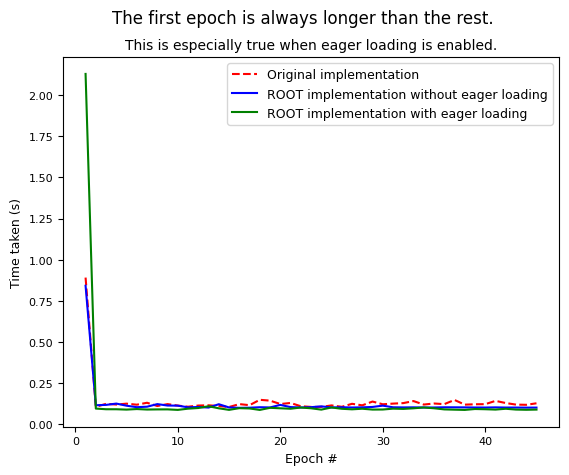

In [23]:
epochs = [i+1 for i in range(45)]
OG_epoch_times = [0.8914915240020491, 0.10677140500047244, 0.12459117400067043, 0.12037469700226211, 0.12587540299864486, 0.11952173700046842, 0.1312585979976575, 0.11155228200004785, 0.12311806100115064, 0.11405819100036751, 0.10712982800032478, 0.11439212699769996, 0.11588871400090284, 0.11145890600164421, 0.10541933000058634, 0.12307962900013081, 0.11663346100249328,0.1492049339976802, 0.14419389700196916, 0.12358465600118507, 0.12998284599962062, 0.1102279480001016, 0.10601607900025556, 0.1060905489975994, 0.11518704799891566, 0.1067911930003902, 0.12493774399990798, 0.11566480400142609, 0.1386282889980066, 0.12209210800210712, 0.1261149120000482, 0.12917091300187167, 0.14158007499645464, 0.12028959699819097, 0.12682300000233226, 0.12284404800084303, 0.14829995699983556, 0.11984975199811743, 0.12208888100212789, 0.12272859099903144, 0.14273144399703597, 0.1295946179998282, 0.12003514999742038, 0.11881949000235181, 0.12799795299724792]
no_eager_loading_epoch_times = [0.8418617589995847, 0.11616583399882074, 0.1183575640025083, 0.12625707799816155, 0.1133988239998871, 0.10438110299946857, 0.10736584099868196, 0.12310559799880139, 0.1143963549984619, 0.11376208599904203, 0.10357952000049409, 0.10552556900074705, 0.10217316199850757, 0.12238929500017548, 0.10277118399972096, 0.10052549200190697, 0.10119914499955485, 0.10412887999700615, 0.10285122300047078, 0.11827741399974911, 0.10502269599965075, 0.10259219799991115, 0.10443948300235206, 0.10933666600249126, 0.10299474299972644, 0.10402915299710003, 0.10246864600048866, 0.10330039600012242, 0.1058462809996854, 0.11380234099851805, 0.10381303800022579, 0.10298325099938666, 0.10344741199878627, 0.10247031999824685, 0.10253873799956637, 0.1037523940030951, 0.10357447999922442, 0.1031995069970435, 0.1025312239980849, 0.10229589200025657, 0.10331200800283113, 0.10217274100068607, 0.10218450300089899, 0.10167836399705266, 0.10194600699833245]
eager_loading_epoch_times = [2.128277350002463, 0.09596747400064487, 0.09190063700225437, 0.09179227400090895, 0.08973669900296954, 0.09303685800114181, 0.09009986100136302, 0.09086806100094691, 0.09112324999659904, 0.08798911200210568, 0.09535820199744194, 0.09936199000003398, 0.11004939299891703, 0.09757514900047681, 0.08815521300130058, 0.09839058899888187, 0.09665512400169973,0.08777731400186894, 0.10060033199988538, 0.09764943800109904, 0.09495483600039734, 0.10231478800051264, 0.09775103900028626, 0.08959050500197918, 0.1026343170015025, 0.09464585599926068, 0.09141798199925688, 0.09497636499872897, 0.08987459699710598, 0.09026919800089672, 0.0954359770003066, 0.09395022099852213, 0.09760194900081842, 0.10258252000130597, 0.0978022260023863, 0.0909577980019094, 0.08929813800205011, 0.0878506440021738, 0.09327177799787023, 0.09193751699785935, 0.0898211089988763, 0.09479940199889825, 0.0899270180016174, 0.08864657700178213, 0.08980110099946614]

fig = plt.figure()
ax = plt.axes()

ax.plot(epochs, OG_epoch_times, color="red", linestyle="--", label="Original implementation")
ax.plot(epochs, no_eager_loading_epoch_times, color="blue", label="ROOT implementation without eager loading")
ax.plot(epochs, eager_loading_epoch_times, color="green", label="ROOT implementation with eager loading")

plt.xlabel("Epoch #")
plt.ylabel("Time taken (s)")
plt.legend()
plt.suptitle("The first epoch is always longer than the rest.", fontsize=12)
plt.title("This is especially true when eager loading is enabled.", fontsize=10)

In [32]:
with open("../mprofile_20260623155335.dat") as f:
    mems = []
    times = []
    firstTime = 0
    for line in f:
        line = line.split()
        try:
            mems.append(float(line[1]))
        except:
            continue
        if firstTime == 0:
            firstTime = float(line[2])
        times.append(float(line[2])-firstTime)

    print(mems)
    print(times)

[0.566406, 30.542969, 45.144531, 67.527344, 108.433594, 191.953125, 339.449219, 353.53125, 362.425781, 376.804688, 392.304688, 400.6875, 533.578125, 566.628906, 570.078125, 585.351562, 596.15625, 624.734375, 627.75, 643.230469, 668.171875, 680.574219, 705.367188, 706.695312, 718.433594, 731.914062, 766.152344, 768.816406, 770.246094, 772.957031, 772.957031, 774.269531, 774.796875, 775.339844, 775.339844, 777.054688, 783.402344, 783.960938, 785.882812, 789.566406, 791.261719, 801.640625, 822.257812, 823.109375, 825.652344, 828.730469, 830.40625, 831.996094, 833.761719, 835.460938, 836.15625, 837.121094, 837.417969, 838.328125, 839.195312, 839.640625, 841.042969, 841.644531, 842.046875, 842.132812, 842.609375, 843.207031, 843.710938, 843.757812, 843.828125, 843.914062, 844.109375, 844.527344, 844.886719, 840.199219, 841.539062, 841.671875, 842.085938, 842.71875, 843.273438, 843.351562, 843.488281, 843.839844, 844.207031, 844.46875, 844.441406, 844.464844, 844.589844, 844.859375, 845.1054

Text(0.5, 1.0, 'Almost all the rest of the memory comes from imports')

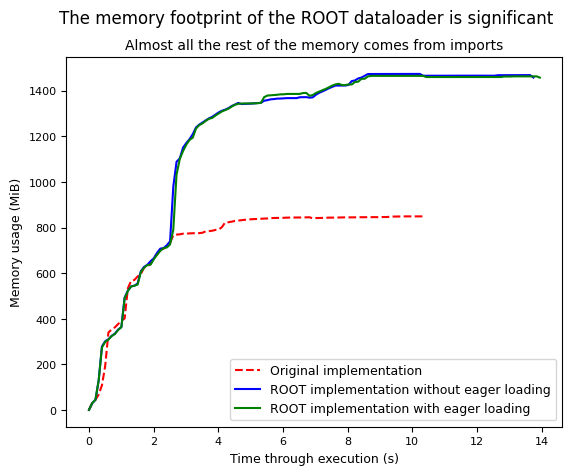

In [31]:
og_mems = [0.566406, 30.542969, 45.144531, 67.527344, 108.433594, 191.953125, 339.449219, 353.53125, 362.425781, 376.804688, 392.304688, 400.6875, 533.578125, 566.628906, 570.078125, 585.351562, 596.15625, 624.734375, 627.75, 643.230469, 668.171875, 680.574219, 705.367188, 706.695312, 718.433594, 731.914062, 766.152344, 768.816406, 770.246094, 772.957031, 772.957031, 774.269531, 774.796875, 775.339844, 775.339844, 777.054688, 783.402344, 783.960938, 785.882812, 789.566406, 791.261719, 801.640625, 822.257812, 823.109375, 825.652344, 828.730469, 830.40625, 831.996094, 833.761719, 835.460938, 836.15625, 837.121094, 837.417969, 838.328125, 839.195312, 839.640625, 841.042969, 841.644531, 842.046875, 842.132812, 842.609375, 843.207031, 843.710938, 843.757812, 843.828125, 843.914062, 844.109375, 844.527344, 844.886719, 840.199219, 841.539062, 841.671875, 842.085938, 842.71875, 843.273438, 843.351562, 843.488281, 843.839844, 844.207031, 844.46875, 844.441406, 844.464844, 844.589844, 844.859375, 845.105469, 845.125, 845.300781, 845.363281, 845.433594, 845.28125, 845.648438, 845.964844, 845.964844, 848.050781, 848.050781, 848.148438, 848.496094, 848.769531, 848.769531, 848.769531, 848.769531, 848.769531, 848.769531, 848.777344]
og_times = [0.0, 0.10030007362365723, 0.2005000114440918, 0.300800085067749, 0.40110015869140625, 0.501500129699707, 0.6017000675201416, 0.7020001411437988, 0.802300214767456, 0.9026000499725342, 1.0029001235961914, 1.1032001972198486, 1.2035000324249268, 1.3037002086639404, 1.4040000438690186, 1.5043001174926758, 1.604600191116333, 1.7049000263214111, 1.8052000999450684, 1.9055001735687256, 2.0058000087738037, 2.106100082397461, 2.206400156021118, 2.3067002296447754, 2.4070000648498535, 2.5073001384735107, 2.607600212097168, 2.7083001136779785, 2.8086001873016357, 2.908900022506714, 3.009200096130371, 3.1095001697540283, 3.2098000049591064, 3.3101000785827637, 3.410400152206421, 3.510700225830078, 3.6110000610351562, 3.7113001346588135, 3.8116002082824707, 3.911900043487549, 4.012200117111206, 4.112500190734863, 4.212800025939941, 4.313100099563599, 4.413400173187256, 4.51360011100769, 4.613900184631348, 4.714200019836426, 4.8144001960754395, 4.914700031280518, 5.015000104904175, 5.115300178527832, 5.21560001373291, 5.315900087356567, 5.416200160980225, 5.516499996185303, 5.61680006980896, 5.717100143432617, 5.817400217056274, 5.917600154876709, 6.017900228500366, 6.118100166320801, 6.218400001525879, 6.318800210952759, 6.419100046157837, 6.519400119781494, 6.619800090789795, 6.720100164413452, 6.82039999961853, 6.920600175857544, 7.020900011062622, 7.121200084686279, 7.2215001583099365, 7.321799993515015, 7.422100067138672, 7.522400140762329, 7.62280011177063, 7.7230000495910645, 7.823400020599365, 7.923600196838379, 8.023900032043457, 8.124200105667114, 8.224500179290771, 8.32480001449585, 8.425100088119507, 8.525400161743164, 8.625600099563599, 8.725900173187256, 8.826200008392334, 8.926500082015991, 9.026800155639648, 9.127100229263306, 9.227400064468384, 9.327600002288818, 9.427900075912476, 9.528200149536133, 9.62850022315979, 9.729400157928467, 9.829800128936768, 9.930100202560425, 10.030400037765503, 10.13070011138916, 10.231200218200684, 10.331500053405762]

no_eager_loading_mems = [0.527344, 29.335938, 44.898438, 129.695312, 278.738281, 301.554688, 310.183594, 325.253906, 334.691406, 352.710938, 363.636719, 492.773438, 523.570312, 542.433594, 544.894531, 554.515625, 608.652344, 627.464844, 636.746094, 652.554688, 665.4375, 689.296875, 707.550781, 709.78125, 722.054688, 739.382812, 979.761719, 1088.140625, 1103.058594, 1150.125, 1170.339844, 1187.175781, 1209.113281, 1238.667969, 1251.03125, 1260.492188, 1269.558594, 1278.484375, 1285.289062, 1294.820312, 1304.679688, 1311.789062, 1316.53125, 1323.300781, 1332.46875, 1338.847656, 1345.960938, 1341.125, 1341.6875, 1342.179688, 1343.019531, 1344.300781, 1345.359375, 1346.5625, 1355.71875, 1358.222656, 1361.746094, 1362.914062, 1364.949219, 1365.214844, 1366.035156, 1367.085938, 1367.097656, 1367.101562, 1367.121094, 1370.976562, 1370.976562, 1371.429688, 1368.988281, 1370.609375, 1382.402344, 1390.550781, 1396.753906, 1403.324219, 1410.683594, 1416.207031, 1422.1875, 1422.25, 1422.3125, 1422.3125, 1424.886719, 1441.734375, 1444.539062, 1453.425781, 1457.28125, 1465.160156, 1472.726562, 1472.730469, 1472.996094, 1473.011719, 1472.804688, 1472.824219, 1472.894531, 1472.914062, 1472.917969, 1472.917969, 1472.925781, 1472.929688, 1472.933594, 1473.148438, 1472.941406, 1473.160156, 1473.164062, 1465.199219, 1465.234375, 1465.261719, 1465.261719, 1465.269531, 1465.269531, 1465.277344, 1465.492188, 1465.492188, 1465.28125, 1465.292969, 1465.300781, 1465.300781, 1465.300781, 1465.300781, 1465.316406, 1465.316406, 1465.527344, 1465.34375, 1465.324219, 1465.328125, 1465.328125, 1465.328125, 1467.496094, 1467.496094, 1467.496094, 1467.496094, 1467.871094, 1467.871094, 1467.871094, 1467.871094, 1467.960938, 1467.960938, 1467.96875, 1457.339844]
no_eager_loading_times = [0.0, 0.10029983520507812, 0.20079994201660156, 0.3011000156402588, 0.4013998508453369, 0.5016999244689941, 0.6019999980926514, 0.7022998332977295, 0.8025000095367432, 0.9027998447418213, 1.0032000541687012, 1.1033999919891357, 1.2047998905181885, 1.3050999641418457, 1.4052999019622803, 1.5055999755859375, 1.6059000492095947, 1.7061998844146729, 1.80649995803833, 1.9068000316619873, 2.0070998668670654, 2.1073999404907227, 2.20770001411438, 2.307999849319458, 2.4082000255584717, 2.5085999965667725, 2.6088998317718506, 2.709199905395508, 2.809799909591675, 2.9101998805999756, 3.010499954223633, 3.11080002784729, 3.211099863052368, 3.3113999366760254, 3.4117000102996826, 3.5119998455047607, 3.6124000549316406, 3.7126998901367188, 3.812999963760376, 3.913300037384033, 4.013700008392334, 4.113999843597412, 4.214299917221069, 4.314599990844727, 4.414999961853027, 4.515300035476685, 4.615599870681763, 4.71589994430542, 4.816299915313721, 4.916599988937378, 5.016900062561035, 5.117199897766113, 5.217599868774414, 5.317899942398071, 5.4182000160217285, 5.518499851226807, 5.618799924850464, 5.718999862670898, 5.819399833679199, 5.920099973678589, 6.020400047302246, 6.12089991569519, 6.221199989318848, 6.321500062942505, 6.421799898147583, 6.52209997177124, 6.6224000453948975, 6.722699880599976, 6.822999954223633, 6.92330002784729, 7.023599863052368, 7.123999834060669, 7.224299907684326, 7.324599981307983, 7.424900054931641, 7.525300025939941, 7.6255998611450195, 7.725899934768677, 7.8262999057769775, 7.926499843597412, 8.02679991722107, 8.12719988822937, 8.227400064468384, 8.327800035476685, 8.428099870681763, 8.52839994430542, 8.628700017929077, 8.728999853134155, 8.829299926757812, 8.929499864578247, 9.02970004081726, 9.129999876022339, 9.230299949645996, 9.330600023269653, 9.430899858474731, 9.531199932098389, 9.631500005722046, 9.731799840927124, 9.832099914550781, 9.932399988174438, 10.032700061798096, 10.133100032806396, 10.233399868011475, 10.333699941635132, 10.434000015258789, 10.534299850463867, 10.634599924087524, 10.734799861907959, 10.835099935531616, 10.935400009155273, 11.035699844360352, 11.135999917984009, 11.236299991607666, 11.336600065231323, 11.436899900436401, 11.537199974060059, 11.637500047683716, 11.737799882888794, 11.838099956512451, 11.938400030136108, 12.038599967956543, 12.1389000415802, 12.239199876785278, 12.339499950408936, 12.439800024032593, 12.540099859237671, 12.640399932861328, 12.740700006484985, 12.840999841690063, 12.94129991531372, 13.041599988937378, 13.141999959945679, 13.242300033569336, 13.342599868774414, 13.442899942398071, 13.543200016021729, 13.644000053405762, 13.74429988861084]

eager_loading_mems = [0.550781, 30.460938, 45.113281, 129.480469, 273.707031, 298.832031, 308.914062, 324.121094, 333.667969, 350.757812, 363.621094, 490.179688, 521.914062, 541.375, 544.722656, 549.816406, 605.429688, 623.707031, 635.472656, 637.007812, 660.816406, 680.457031, 697.722656, 709.496094, 712.601562, 725.6875, 790.195312, 1031.453125, 1100.132812, 1134.855469, 1162.722656, 1183.761719, 1193.476562, 1233.71875, 1248.820312, 1256.207031, 1267.261719, 1276.519531, 1280.273438, 1290.847656, 1299.519531, 1308.679688, 1314.761719, 1320.753906, 1329.9375, 1338.078125, 1342.09375, 1343.152344, 1343.714844, 1343.714844, 1343.714844, 1344.046875, 1344.867188, 1346.113281, 1371.214844, 1378.347656, 1379.378906, 1380.777344, 1381.710938, 1383.628906, 1383.714844, 1385.46875, 1385.46875, 1385.484375, 1385.503906, 1385.507812, 1389.363281, 1389.800781, 1377.207031, 1380.65625, 1389.808594, 1396.066406, 1401.878906, 1407.617188, 1414.976562, 1421.976562, 1427.34375, 1429.964844, 1424.21875, 1424.3125, 1426.96875, 1426.964844, 1437.800781, 1439.203125, 1451.695312, 1451.90625, 1462.304688, 1464.691406, 1464.488281, 1464.535156, 1464.5625, 1464.5625, 1464.578125, 1464.589844, 1464.589844, 1464.59375, 1464.605469, 1464.816406, 1464.820312, 1464.609375, 1464.613281, 1464.613281, 1464.613281, 1464.613281, 1459.527344, 1459.53125, 1459.53125, 1459.53125, 1459.53125, 1459.617188, 1459.53125, 1459.742188, 1459.742188, 1459.554688, 1459.53125, 1459.554688, 1459.558594, 1459.558594, 1459.566406, 1459.578125, 1459.578125, 1459.578125, 1459.578125, 1459.582031, 1459.585938, 1459.585938, 1459.589844, 1459.589844, 1461.757812, 1461.757812, 1461.757812, 1462.460938, 1462.484375, 1462.484375, 1462.484375, 1462.484375, 1462.542969, 1462.542969, 1462.550781, 1456.894531]
eager_loading_times = [0.0, 0.10030007362365723, 0.2005000114440918, 0.300800085067749, 0.40110015869140625, 0.5013999938964844, 0.602100133895874, 0.7023999691009521, 0.8027000427246094, 0.902899980545044, 1.0032999515533447, 1.1035001277923584, 1.2039000988006592, 1.3041999340057373, 1.4045000076293945, 1.5048000812530518, 1.605100154876709, 1.705399990081787, 1.8057000637054443, 1.9060001373291016, 2.0062999725341797, 2.1065001487731934, 2.2067999839782715, 2.3071000576019287, 2.407400131225586, 2.507699966430664, 2.6080000400543213, 2.7083001136779785, 2.8085999488830566, 2.908900022506714, 3.0092999935150146, 3.109600067138672, 3.209900140762329, 3.3101999759674072, 3.410900115966797, 3.511199951171875, 3.6115000247955322, 3.7118000984191895, 3.8122000694274902, 3.9125001430511475, 4.012799978256226, 4.113199949264526, 4.213500022888184, 4.313800096511841, 4.414200067520142, 4.514500141143799, 4.614799976348877, 4.715199947357178, 4.815500020980835, 4.915800094604492, 5.01609992980957, 5.11650013923645, 5.216799974441528, 5.3171000480651855, 5.417500019073486, 5.5178000926971436, 5.618099927902222, 5.718400001525879, 5.8185999393463135, 5.919000148773193, 6.0192999839782715, 6.119600057601929, 6.219900131225586, 6.320199966430664, 6.420500040054321, 6.5208001136779785, 6.621200084686279, 6.721400022506714, 6.821799993515015, 6.922100067138672, 7.022400140762329, 7.123000144958496, 7.223299980163574, 7.3236000537872314, 7.423900127410889, 7.5243000984191895, 7.624599933624268, 7.724900007247925, 7.825299978256226, 7.926000118255615, 8.026299953460693, 8.12660002708435, 8.226900100708008, 8.327199935913086, 8.427500009536743, 8.5278000831604, 8.628200054168701, 8.728399991989136, 8.828700065612793, 8.929100036621094, 9.029299974441528, 9.129500150680542, 9.22979998588562, 9.330199956893921, 9.430500030517578, 9.530800104141235, 9.631099939346313, 9.731300115585327, 9.831599950790405, 9.931900024414062, 10.03220009803772, 10.132499933242798, 10.232800006866455, 10.333100080490112, 10.43340015411377, 10.533699989318848, 10.634000062942505, 10.734300136566162, 10.83459997177124, 10.934900045394897, 11.035200119018555, 11.135499954223633, 11.23580002784729, 11.335999965667725, 11.436300039291382, 11.536499977111816, 11.636899948120117, 11.737300157546997, 11.837599992752075, 11.937900066375732, 12.03820013999939, 12.138499975204468, 12.238800048828125, 12.339100122451782, 12.43939995765686, 12.539700031280518, 12.640000104904175, 12.74020004272461, 12.84060001373291, 12.940900087356567, 13.041200160980225, 13.141499996185303, 13.24180006980896, 13.342100143432617, 13.442500114440918, 13.542799949645996, 13.643100023269653, 13.74340009689331, 13.843800067901611, 13.944100141525269]


fig = plt.figure()
ax = plt.axes()
ax.plot(og_times, og_mems, linestyle="--", color="red", label="Original implementation")
ax.plot(no_eager_loading_times, no_eager_loading_mems, color="blue", label="ROOT implementation without eager loading")
ax.plot(eager_loading_times, eager_loading_mems, color="green", label="ROOT implementation with eager loading")

plt.xlabel("Time through execution (s)")
plt.ylabel("Memory usage (MiB)")
plt.legend()
plt.suptitle("The memory footprint of the ROOT dataloader is significant", fontsize=12)
plt.title("Almost all the rest of the memory comes from imports", fontsize=10)

In [33]:
# 3x3 grid of memory over execution time, varying batch size and batches in memory.

Text(0.5, 1.0, "The original implementation doesn't need to import ROOT.")

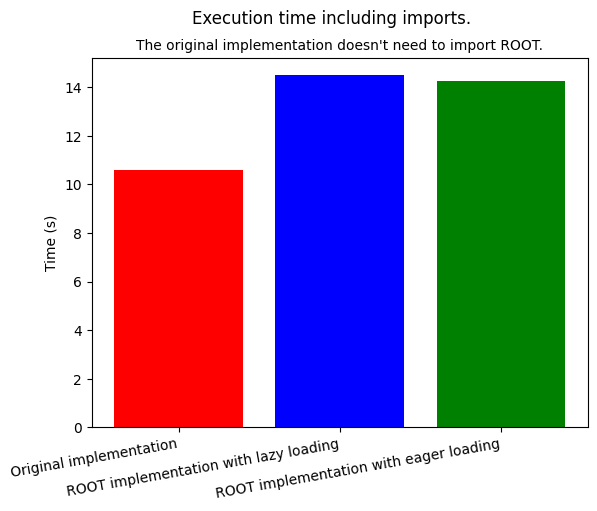

In [17]:
og_avg_time = 10.604650317900087
no_eager_loading_avg_time = 14.490451954400123
eager_loading_avg_time = 14.265890882999884

fig = plt.figure()
ax = plt.axes()
ax.bar("Original implementation", og_avg_time, color="red")
ax.bar("ROOT implementation with lazy loading", no_eager_loading_avg_time, color="blue")
ax.bar("ROOT implementation with eager loading", eager_loading_avg_time, color="green")
plt.xticks(rotation=10, ha="right")
plt.ylabel("Time (s)")
plt.suptitle("Execution time including imports.", fontsize=12)
plt.title("The original implementation doesn't need to import ROOT.", fontsize=10)

Text(0.5, 1.0, "Shuffling the data doesn't increase the runtime.")

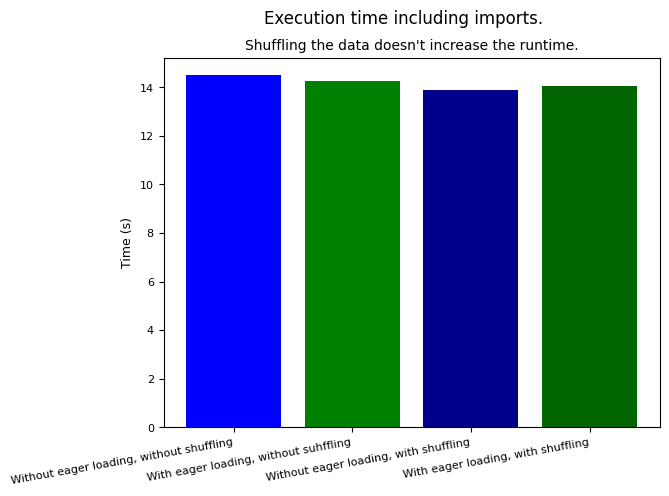

In [ ]:
no_suhffle_no_eager_loading_avg_time = 14.490451954400123
no_shuffle_eager_loading_avg_time = 14.265890882999884
shuffle_no_eager_loading_avg_time = 13.87987933229997
shuffle_eager_loading_avg_time = 14.048667230299907

fig = plt.figure()
ax = plt.axes()
ax.bar("Lazy loading, no shuffling", no_suhffle_no_eager_loading_avg_time, color="blue")
ax.bar("Eager loading, no suhffling", no_shuffle_eager_loading_avg_time, color="green")
ax.bar("Lazy loading, with shuffling", shuffle_no_eager_loading_avg_time, color="darkblue")
ax.bar("Eager loading, with shuffling", shuffle_eager_loading_avg_time, color="darkgreen")

plt.xticks(rotation=10, ha="right")
plt.ylabel("Time (s)")
plt.suptitle("Execution time including imports.", fontsize=12)
plt.title("Shuffling the data doesn't increase the runtime.", fontsize=10)